C:\Users\alexa\AppData\Local\Temp\ipykernel_596\3964867192.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice[1] = pd.to_numeric(df_slice[1], errors='coerce')


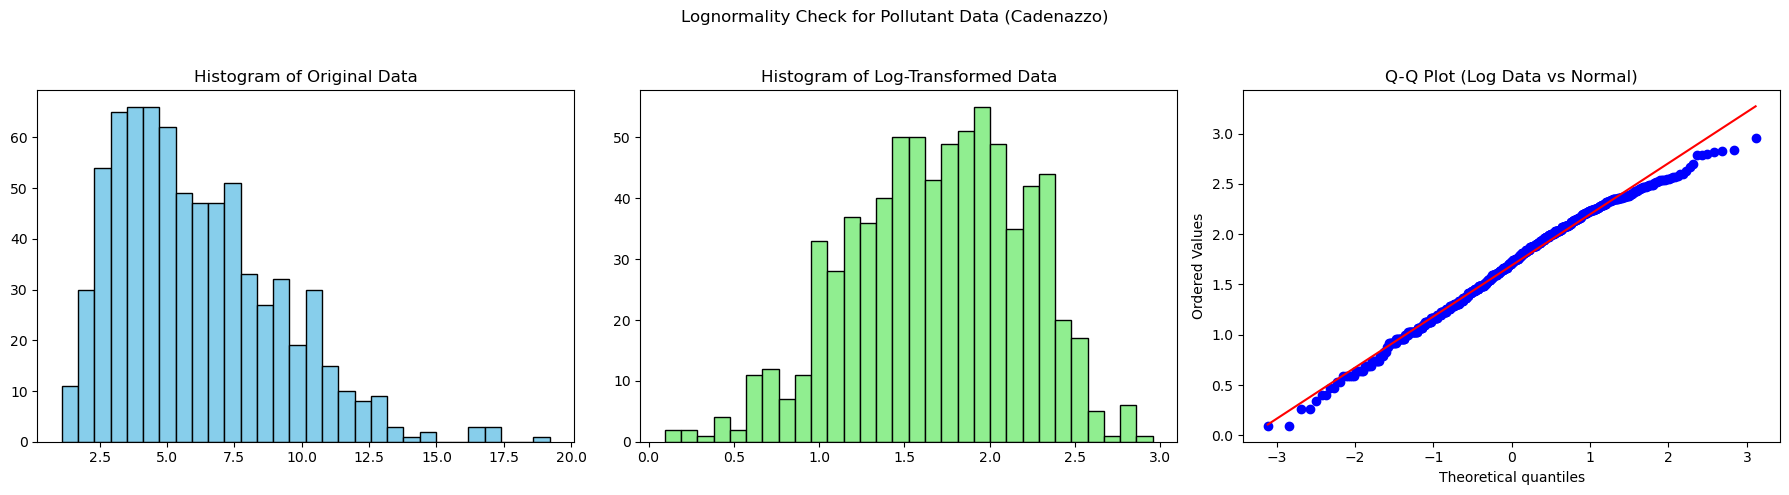

Shapiro-Wilk Test: W=0.9479, p=0.0000
Anderson-Darling Test:
  Statistic: 9.3365
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load CSV without header
file_path = 'NO$_2$.csv'
df = pd.read_csv(file_path, header=None, sep =';')

# Slice rows 4370 to 5113 (index 4369 to 5112)
df_slice = df.iloc[4369:5113]

# Ensure numeric conversion (to handle commas or bad entries gracefully)
df_slice[1] = pd.to_numeric(df_slice[1], errors='coerce')

# Replace NaNs with mean of the column
mean_value = df_slice[1].mean()
data = df_slice[1].fillna(mean_value)

# Remove zeros and negative values
data = data[data > 0]

# Log-transform the data
log_data = np.log(data)

# Shapiro-Wilk test (returns statistic and p-value)
shapiro_stat, shapiro_p = stats.shapiro(log_data)

# Anderson-Darling test
anderson_result = stats.anderson(log_data, dist='norm')

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of original data
axs[0].hist(data, bins=30, color='skyblue', edgecolor='black')
axs[0].set_title("Histogram of Original Data")

# Histogram of log-transformed data
axs[1].hist(log_data, bins=30, color='lightgreen', edgecolor='black')
axs[1].set_title("Histogram of Log-Transformed Data")

# Q-Q plot
stats.probplot(log_data, dist="norm", plot=axs[2])
axs[2].set_title("Q-Q Plot (Log Data vs Normal)")

plt.suptitle("Lognormality Check for Pollutant Data (Cadenazzo)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print test results
print(f"Shapiro-Wilk Test: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("Anderson-Darling Test:")
print(f"  Statistic: {anderson_result.statistic:.4f}")
for cv, sl in zip(anderson_result.critical_values, anderson_result.significance_level):
    print(f"  {sl}%: {cv}")

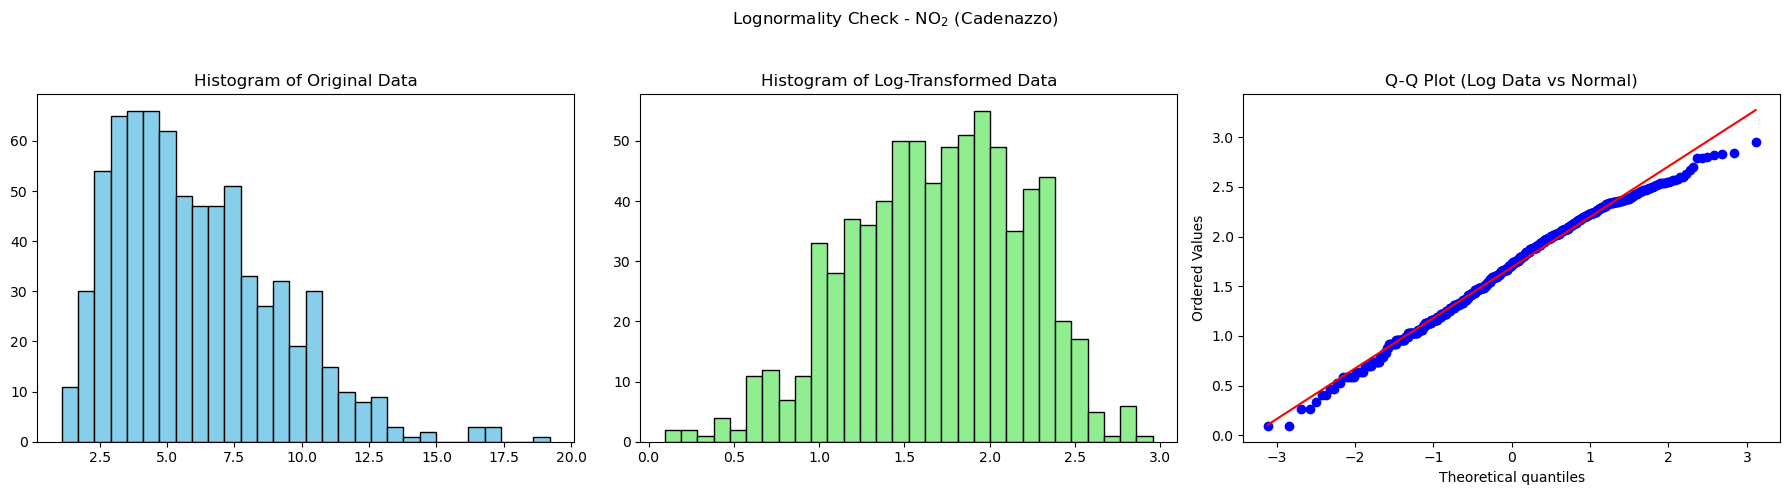


📌 Results for NO$_2$ - Cadenazzo
Shapiro-Wilk Test: W=0.9901, p=0.0001
Anderson-Darling Test:
  Statistic: 1.9348
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


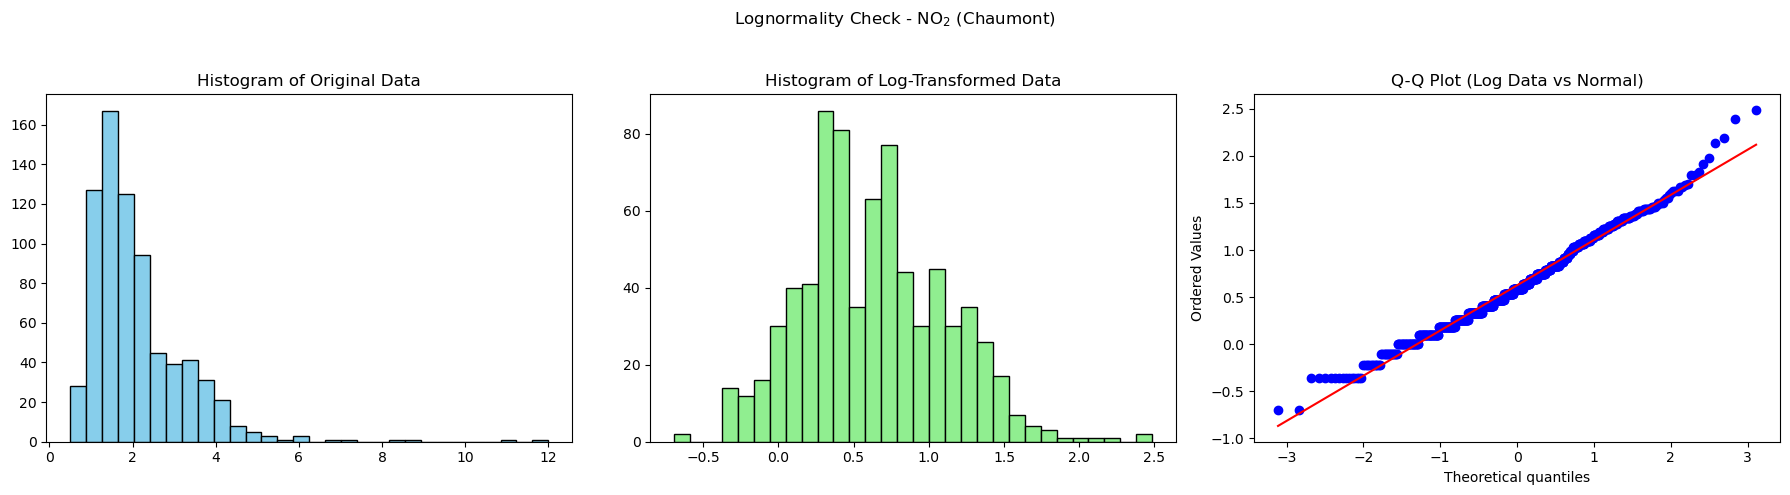


📌 Results for NO$_2$ - Chaumont
Shapiro-Wilk Test: W=0.9885, p=0.0000
Anderson-Darling Test:
  Statistic: 2.5054
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


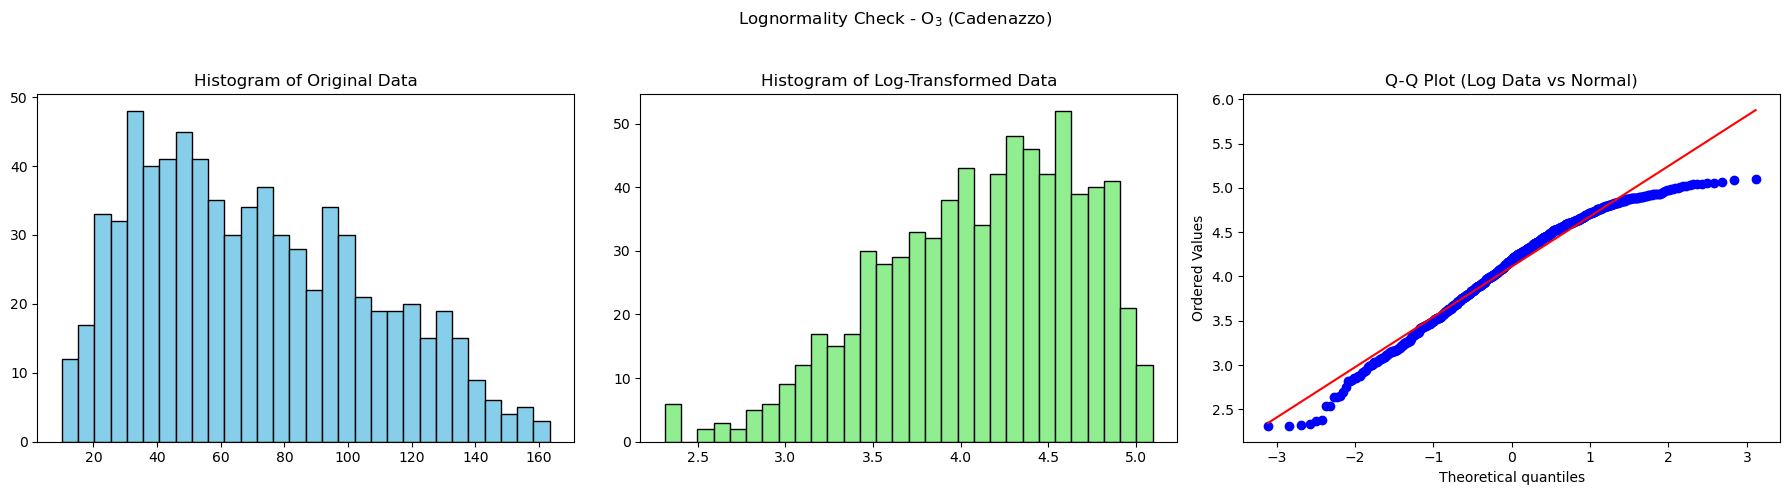


📌 Results for O$_3$ - Cadenazzo
Shapiro-Wilk Test: W=0.9662, p=0.0000
Anderson-Darling Test:
  Statistic: 5.9338
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


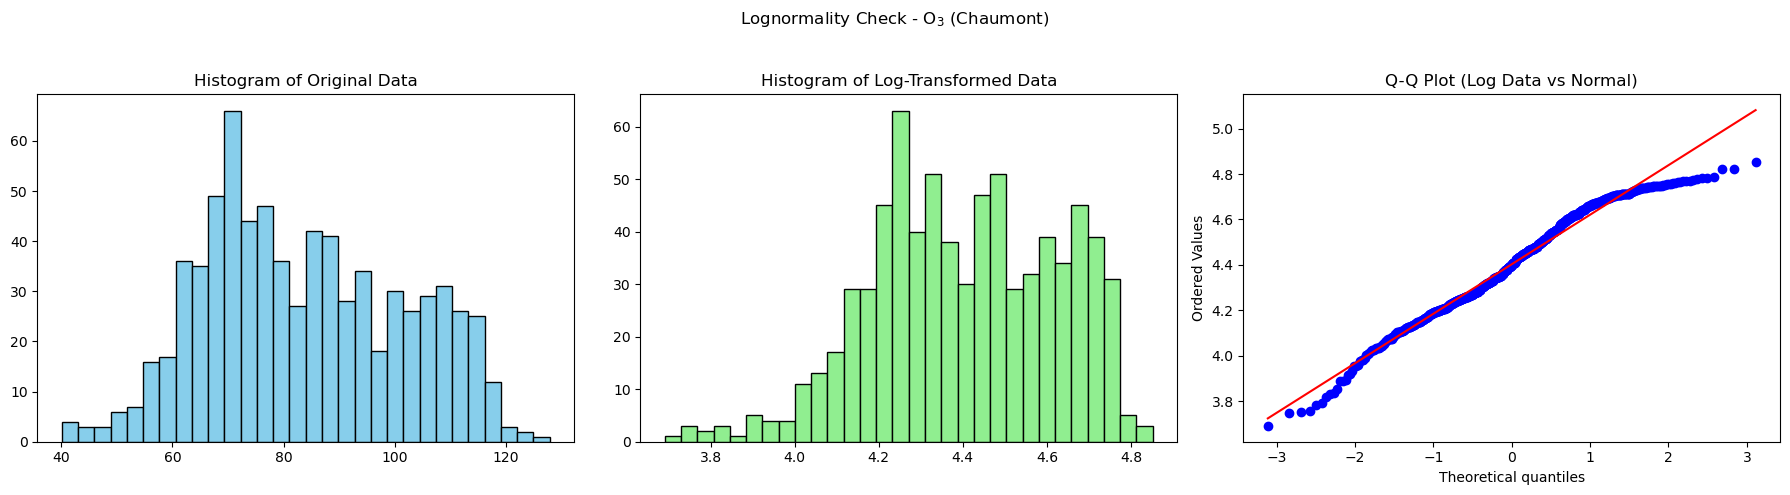


📌 Results for O$_3$ - Chaumont
Shapiro-Wilk Test: W=0.9783, p=0.0000
Anderson-Darling Test:
  Statistic: 3.8181
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


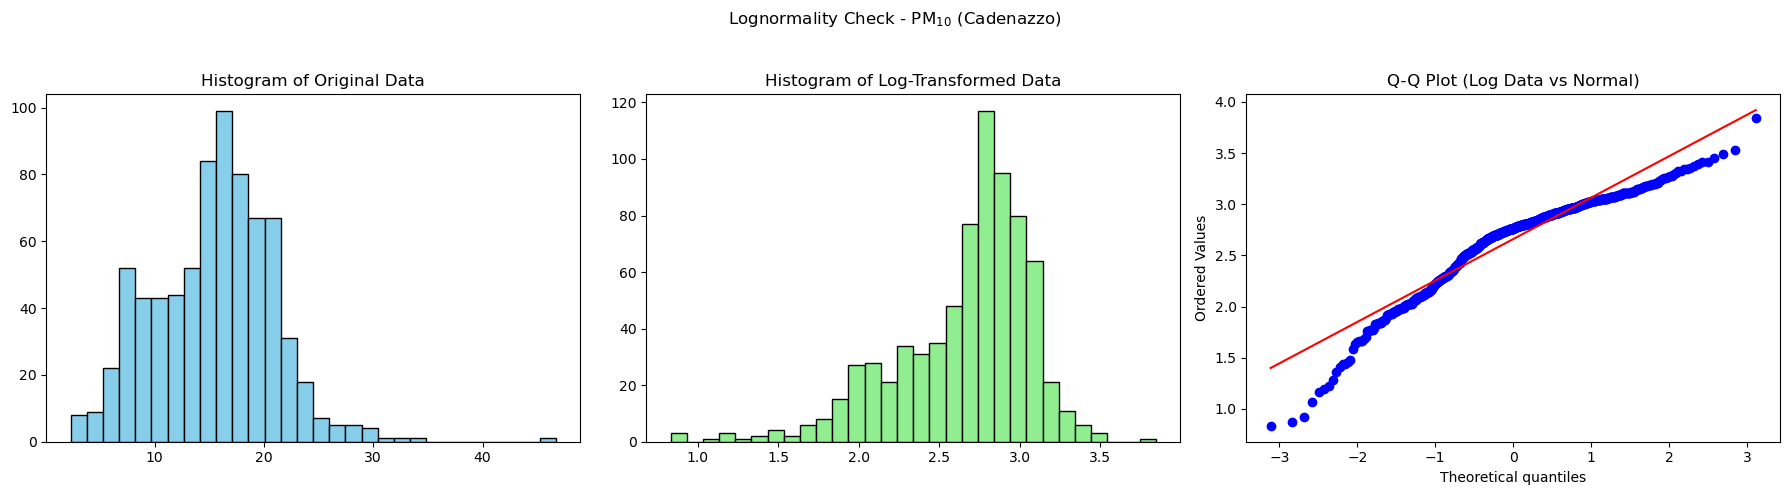


📌 Results for PM$_1$$_0$ - Cadenazzo
Shapiro-Wilk Test: W=0.9242, p=0.0000
Anderson-Darling Test:
  Statistic: 17.9419
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


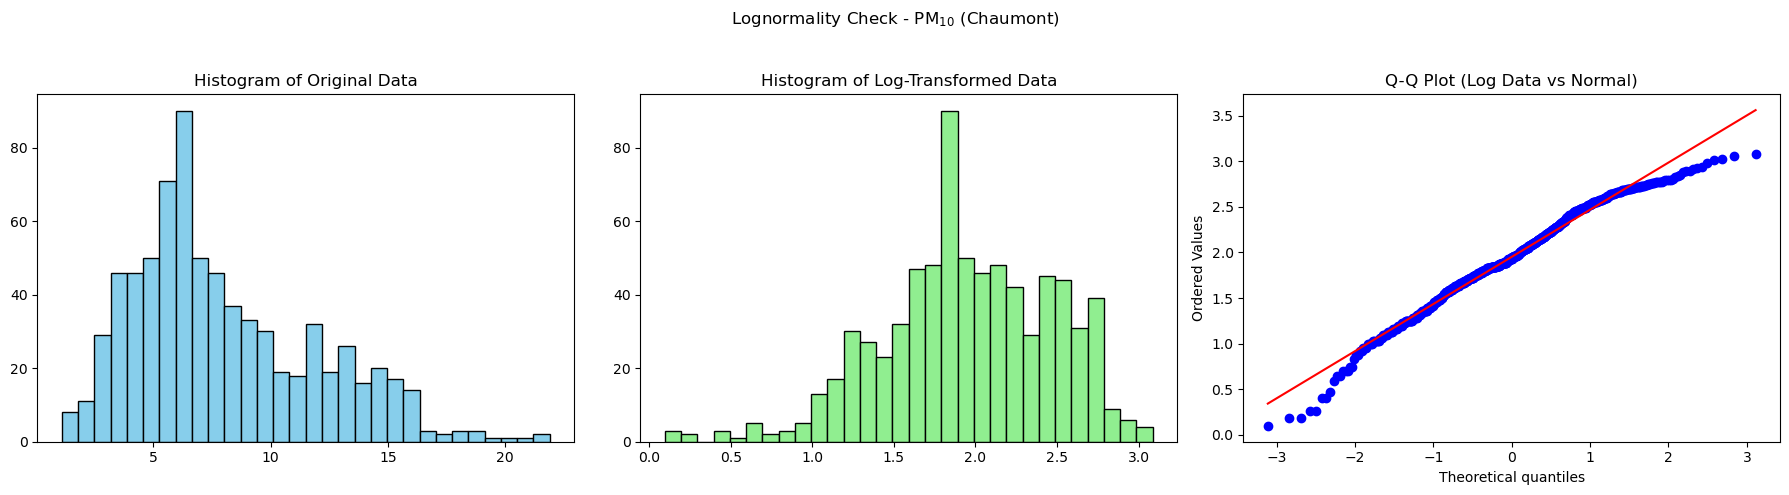


📌 Results for PM$_1$$_0$ - Chaumont
Shapiro-Wilk Test: W=0.9828, p=0.0000
Anderson-Darling Test:
  Statistic: 2.1355
  15.0%: 0.573
  10.0%: 0.653
  5.0%: 0.783
  2.5%: 0.913
  1.0%: 1.086


FileNotFoundError: [Errno 2] No such file or directory: 'PM$_2$$_.$$_5$'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

# Function to test for lognormality and plot results for one column (site)
def analyze_site(data, site_name, pollutant_name):
    data = pd.to_numeric(data, errors='coerce')
    mean_value = data.mean()
    data = data.fillna(mean_value)
    data = data[data > 0]
    log_data = np.log(data)

    # Tests
    shapiro_stat, shapiro_p = stats.shapiro(log_data)
    anderson_result = stats.anderson(log_data, dist='norm')

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].hist(data, bins=30, color='skyblue', edgecolor='black')
    axs[0].set_title("Histogram of Original Data")

    axs[1].hist(log_data, bins=30, color='lightgreen', edgecolor='black')
    axs[1].set_title("Histogram of Log-Transformed Data")

    stats.probplot(log_data, dist="norm", plot=axs[2])
    axs[2].set_title("Q-Q Plot (Log Data vs Normal)")

    plt.suptitle(f"Lognormality Check - {pollutant_name} ({site_name})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Print test results
    print(f"\n📌 Results for {pollutant_name} - {site_name}")
    print(f"Shapiro-Wilk Test: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
    print("Anderson-Darling Test:")
    print(f"  Statistic: {anderson_result.statistic:.4f}")
    for cv, sl in zip(anderson_result.critical_values, anderson_result.significance_level):
        print(f"  {sl}%: {cv:.3f}")

# Main function to loop through files and sites
def process_pollutants(file_list):
    for file_path in file_list:
        pollutant_name = os.path.splitext(os.path.basename(file_path))[0]
        df = pd.read_csv(file_path, header=None, sep=';')
        df_slice = df.iloc[4369:5113]

        # Site 1: Cadenazzo (column 1)
        analyze_site(df_slice[1], 'Cadenazzo', pollutant_name)

        # Site 2: Chaumont (column 2)
        if pollutant_name not in ['SO$_2$', 'PM$_2$$_.$$_5$']:
            analyze_site(df_slice[2], 'Chaumont', pollutant_name)
        else:
            print(f"⏭️ Skipping Chaumont for {pollutant_name} (data not available)")

# Example usage
pollutant_files = [
    'NO$_2$.csv',
    'O$_3$.csv', 
    'PM$_1$$_0$.csv',
    'PM$_2$$_.$$_5$',
    'SO$_2$.csv'
]
process_pollutants(pollutant_files)